<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/10_video_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 10 — Video Augmentation

## What This Notebook Covers
Video augmentation extends image augmentation into the time dimension.
A video is a sequence of frames, so we must apply transforms either:
- **Spatially** (same transform to every frame — preserves temporal consistency)
- **Temporally** (modify the frame sequence itself — drop, reverse, jitter timing)
- **Combined** (both spatial and temporal together)

The key constraint: spatial augmentations must be applied **identically**
across all frames. If you flip frame 1 but not frame 2 the model sees
a physically impossible video — this hurts rather than helps.

**Techniques covered:**
- Spatial: consistent flip, crop, rotation, colour jitter across all frames
- Temporal: frame dropping, temporal reversal, frame repetition, speed perturbation
- Mixed: spatial + temporal together
- Temporal segment sampling strategies
- PyTorchVideo augmentation pipeline
- Action recognition classifier (3D CNN / CNN + temporal pooling)
- A/B test: no augmentation vs full video augmentation pipeline

**Dataset:** UCF-101 subset (or synthetic video sequences for Colab demo)


In [1]:
!pip install pytorchvideo av --quiet

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import HMDB51
import os

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 51.3 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
Device  : cuda


## 1. Synthetic Video Generator

Real video datasets (UCF-101, Kinetics) are large and slow to download
in Colab. We generate synthetic videos — moving coloured shapes —
that are large enough to demonstrate all augmentation techniques clearly.
The augmentation patterns transfer directly to real video datasets.


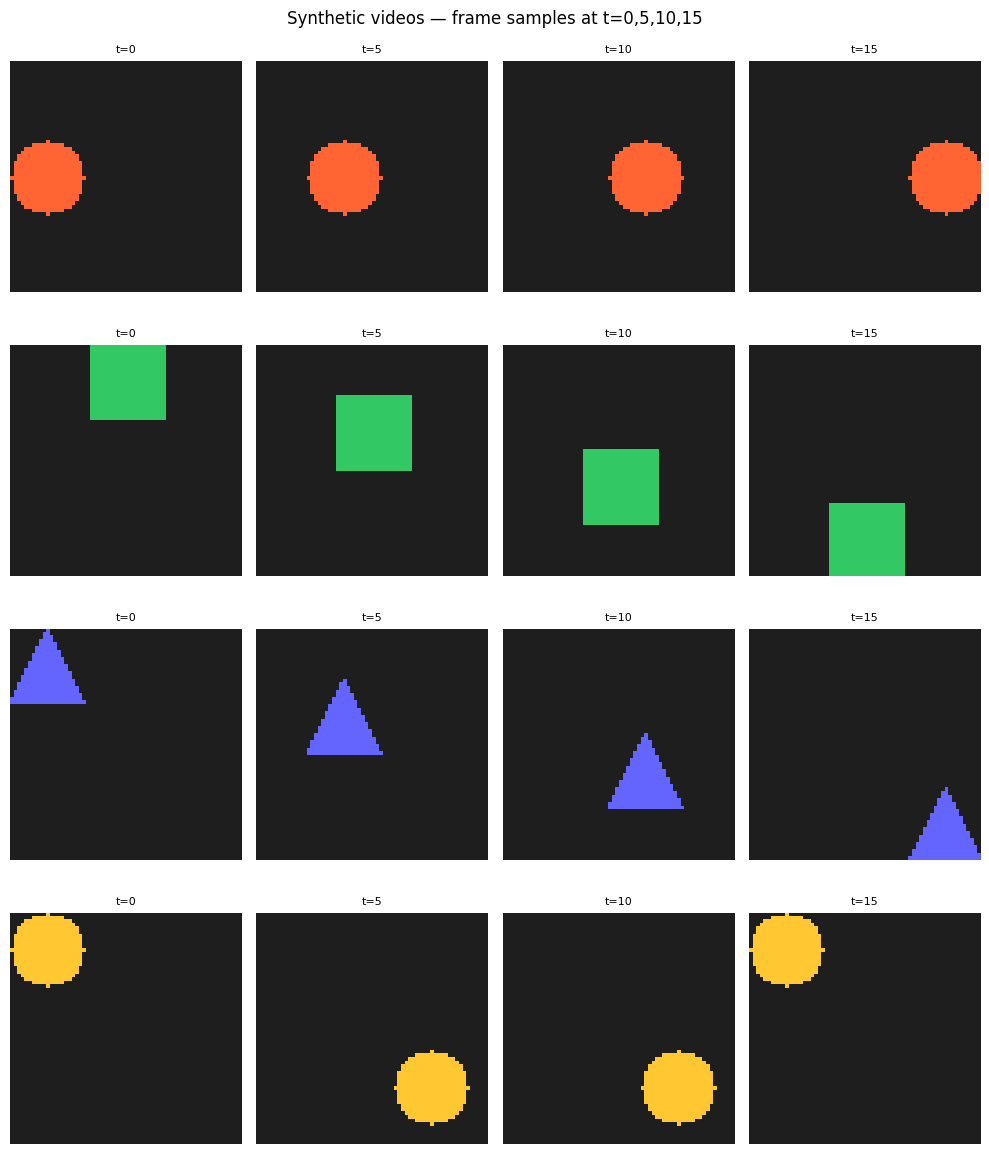

Video shape: (16, 64, 64, 3)  (T, H, W, C)


In [2]:
def make_synthetic_video(n_frames=16, height=64, width=64,
                          shape='circle', color=(255, 100, 50),
                          motion='horizontal'):
    """
    Generate a synthetic video of a moving coloured shape.

    Returns: numpy array shape (n_frames, H, W, 3) uint8

    shape   : 'circle', 'rectangle', 'triangle'
    motion  : 'horizontal', 'vertical', 'diagonal', 'bounce'
    """
    frames = []
    size   = height // 6   # shape size relative to frame

    for t in range(n_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        frame[:] = (30, 30, 30)   # dark grey background

        progress = t / max(n_frames - 1, 1)

        if motion == 'horizontal':
            cx = int(size + progress * (width - 2 * size))
            cy = height // 2
        elif motion == 'vertical':
            cx = width // 2
            cy = int(size + progress * (height - 2 * size))
        elif motion == 'diagonal':
            cx = int(size + progress * (width  - 2 * size))
            cy = int(size + progress * (height - 2 * size))
        else:  # bounce
            bounce = abs(np.sin(progress * np.pi * 2))
            cx = int(size + bounce * (width  - 2 * size))
            cy = int(size + bounce * (height - 2 * size))

        if shape == 'circle':
            cv2.circle(frame, (cx, cy), size, color, -1)
        elif shape == 'rectangle':
            cv2.rectangle(frame, (cx-size, cy-size), (cx+size, cy+size), color, -1)
        else:  # triangle
            pts = np.array([[cx, cy-size], [cx-size, cy+size], [cx+size, cy+size]])
            cv2.fillPoly(frame, [pts], color)

        frames.append(frame)

    return np.stack(frames)   # (T, H, W, 3) uint8


# Generate a few sample videos
configs = [
    ('circle',    (255, 100,  50), 'horizontal'),
    ('rectangle', ( 50, 200, 100), 'vertical'),
    ('triangle',  (100, 100, 255), 'diagonal'),
    ('circle',    (255, 200,  50), 'bounce'),
]

SAMPLE_VIDEOS = [
    make_synthetic_video(n_frames=16, shape=s, color=c, motion=m)
    for s, c, m in configs
]

# Visualise first and last frames of each video
fig, axes = plt.subplots(len(SAMPLE_VIDEOS), 4, figsize=(10, 3 * len(SAMPLE_VIDEOS)))
frame_indices = [0, 5, 10, 15]
for row, (video, (shape, _, motion)) in enumerate(zip(SAMPLE_VIDEOS, configs)):
    for col, fi in enumerate(frame_indices):
        axes[row, col].imshow(video[fi])
        axes[row, col].set_title(f't={fi}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'{shape}/{motion}', fontsize=8)

plt.suptitle('Synthetic videos — frame samples at t=0,5,10,15', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Video shape: {SAMPLE_VIDEOS[0].shape}  (T, H, W, C)')

## 2. Visualisation Helper


In [3]:
def show_video_aug(original, augmented, title='Video augmentation', n_frames=8):
    """
    Display original and augmented video side by side as frame strips.
    original / augmented: numpy (T, H, W, C) uint8
    """
    # Sample n evenly spaced frames
    T = original.shape[0]
    indices = np.linspace(0, T-1, n_frames, dtype=int)

    fig, axes = plt.subplots(2, n_frames, figsize=(2 * n_frames, 4))
    for i, fi in enumerate(indices):
        axes[0, i].imshow(np.clip(original[fi], 0, 255).astype(np.uint8))
        axes[0, i].set_title(f't={fi}', fontsize=7)
        axes[0, i].axis('off')

        aug_frame = augmented[fi] if fi < len(augmented) else augmented[-1]
        axes[1, i].imshow(np.clip(aug_frame, 0, 255).astype(np.uint8))
        axes[1, i].set_title(f't={fi}', fontsize=7)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Augmented', fontsize=9)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

print('Helper defined.')

Helper defined.


## 3. Spatial Augmentations — Applied Consistently Across Frames

The critical rule for spatial augmentation on video:
sample the random parameters ONCE, then apply the SAME transform
to ALL frames. Never sample new parameters per frame.


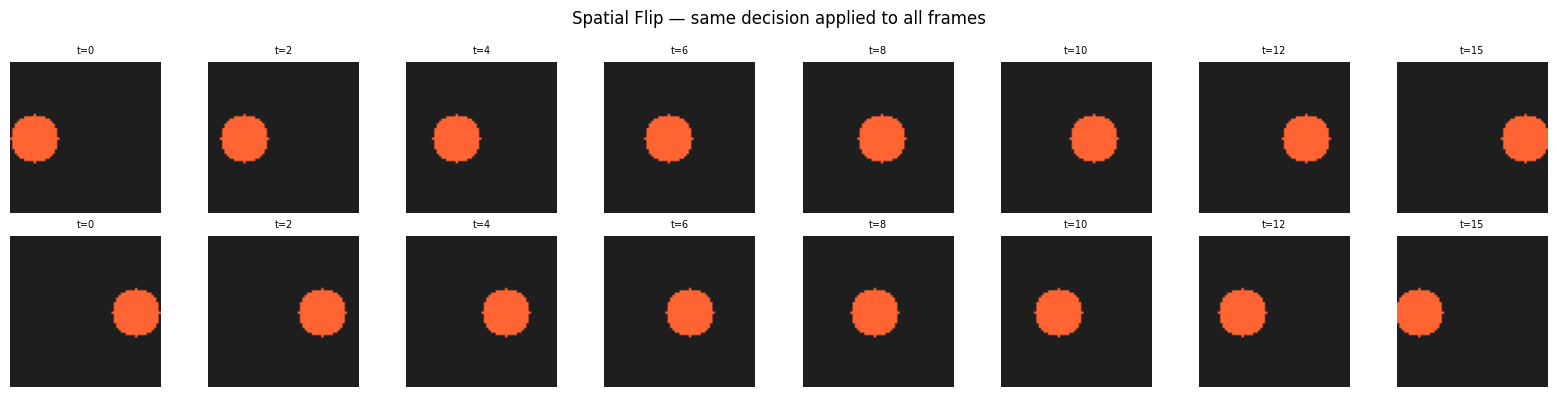

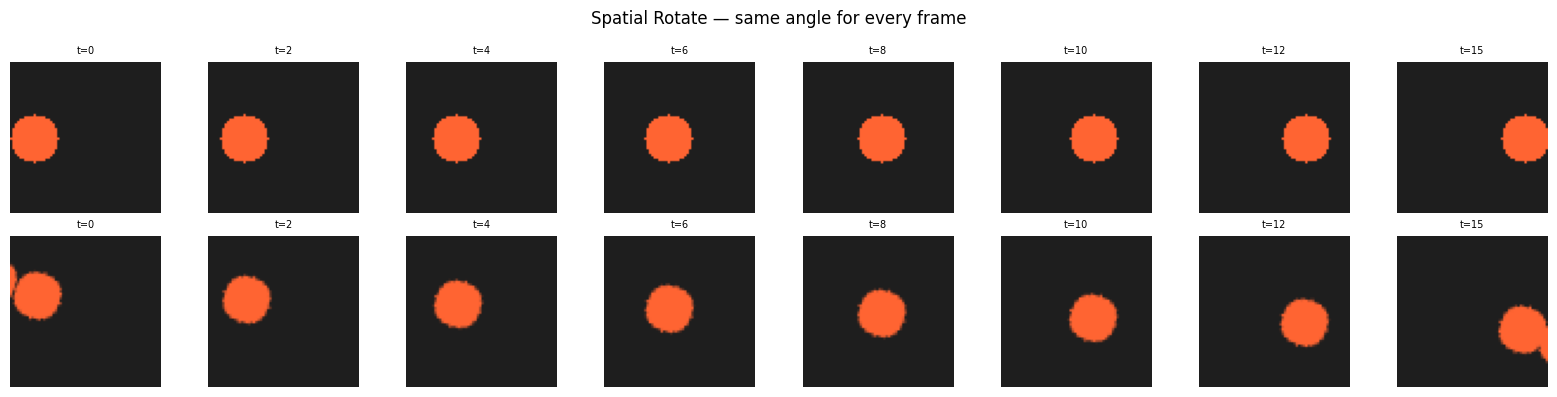

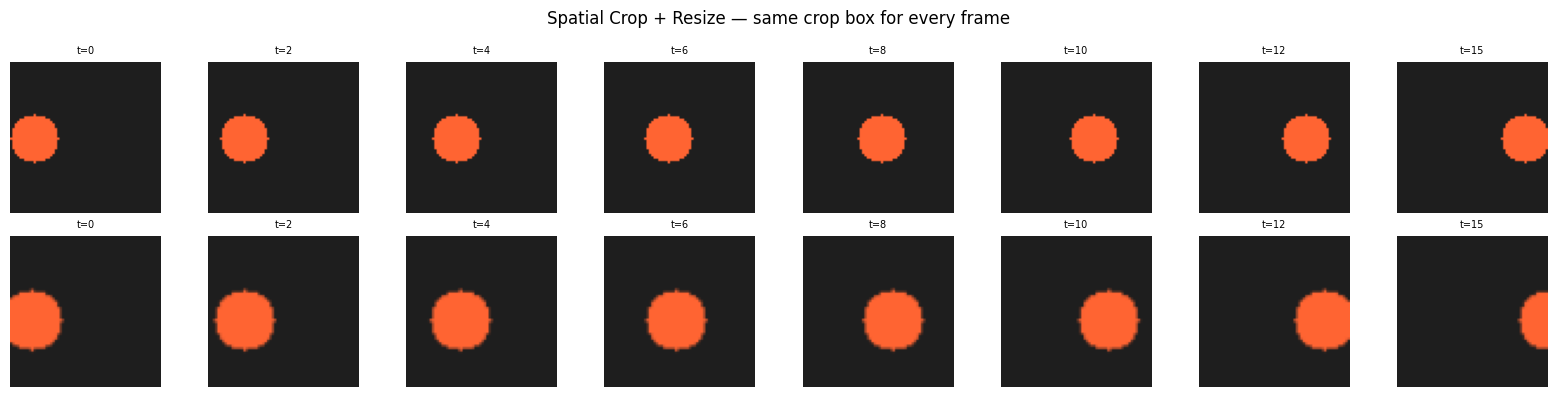

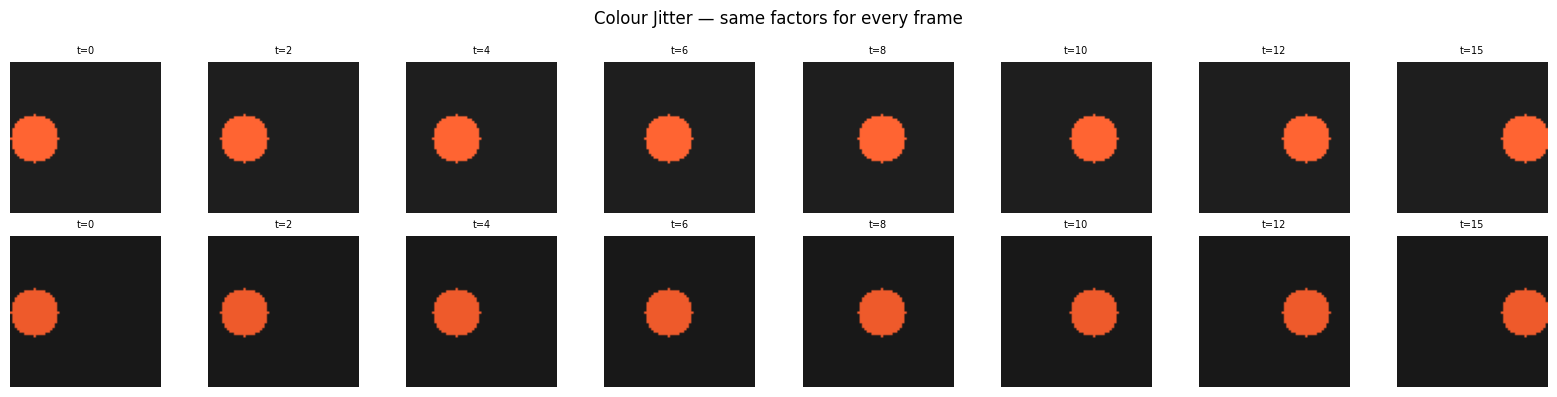

In [4]:
def spatial_flip(video, p=0.5):
    """
    Horizontally flip all frames with probability p.
    Decision is made ONCE and applied to every frame.
    """
    if random.random() < p:
        # np.flip along the width axis (axis=2), then copy to fix negative strides
        return np.flip(video, axis=2).copy()
    return video


def spatial_rotate(video, max_angle=15):
    """
    Rotate all frames by the same random angle.
    Angle is sampled once — same rotation applied to each frame.
    """
    angle = random.uniform(-max_angle, max_angle)
    H, W  = video.shape[1], video.shape[2]
    M     = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)

    rotated = np.stack([
        cv2.warpAffine(frame, M, (W, H), borderMode=cv2.BORDER_REFLECT_101)
        for frame in video
    ])
    return rotated


def spatial_crop(video, crop_frac=0.85):
    """
    Crop a random region from all frames, then resize back to original size.
    The crop rectangle is sampled once and applied consistently.
    """
    T, H, W, C = video.shape
    crop_h = int(H * crop_frac)
    crop_w = int(W * crop_frac)

    # Sample crop origin once
    top  = random.randint(0, H - crop_h)
    left = random.randint(0, W - crop_w)

    cropped = np.stack([
        cv2.resize(
            frame[top:top+crop_h, left:left+crop_w],
            (W, H),
            interpolation=cv2.INTER_LINEAR
        )
        for frame in video
    ])
    return cropped


def spatial_color_jitter(video, brightness=0.3, contrast=0.3, saturation=0.2):
    """
    Apply the same colour jitter to all frames.
    Parameters are sampled once; same values applied to every frame.
    """
    # Sample factors once
    bright_factor = random.uniform(1 - brightness, 1 + brightness)
    contrast_factor = random.uniform(1 - contrast, 1 + contrast)

    jittered = []
    for frame in video:
        f = frame.astype(np.float32)
        # Brightness
        f = np.clip(f * bright_factor, 0, 255)
        # Contrast: move toward mean
        mean = f.mean()
        f = np.clip((f - mean) * contrast_factor + mean, 0, 255)
        jittered.append(f.astype(np.uint8))

    return np.stack(jittered)


video = SAMPLE_VIDEOS[0]

show_video_aug(video, spatial_flip(video, p=1.0),
               title='Spatial Flip — same decision applied to all frames')

show_video_aug(video, spatial_rotate(video, max_angle=20),
               title='Spatial Rotate — same angle for every frame')

show_video_aug(video, spatial_crop(video, crop_frac=0.8),
               title='Spatial Crop + Resize — same crop box for every frame')

show_video_aug(video, spatial_color_jitter(video),
               title='Colour Jitter — same factors for every frame')

## 4. Temporal Augmentations — Modifying the Frame Sequence

Temporal augmentations change WHICH frames are used and in what order.
These have no image-space equivalent — they operate on the time axis.


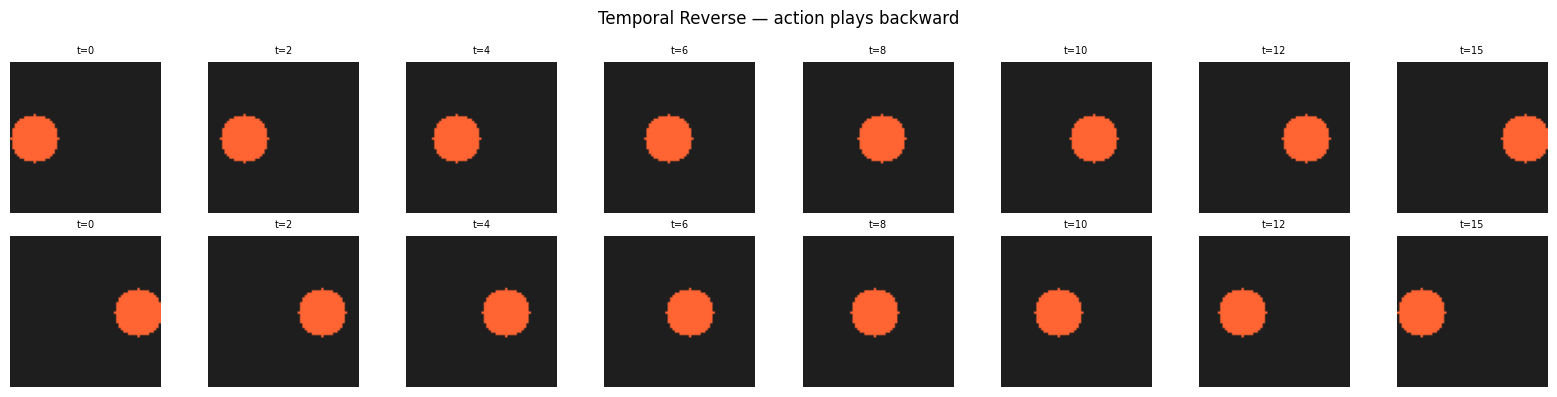

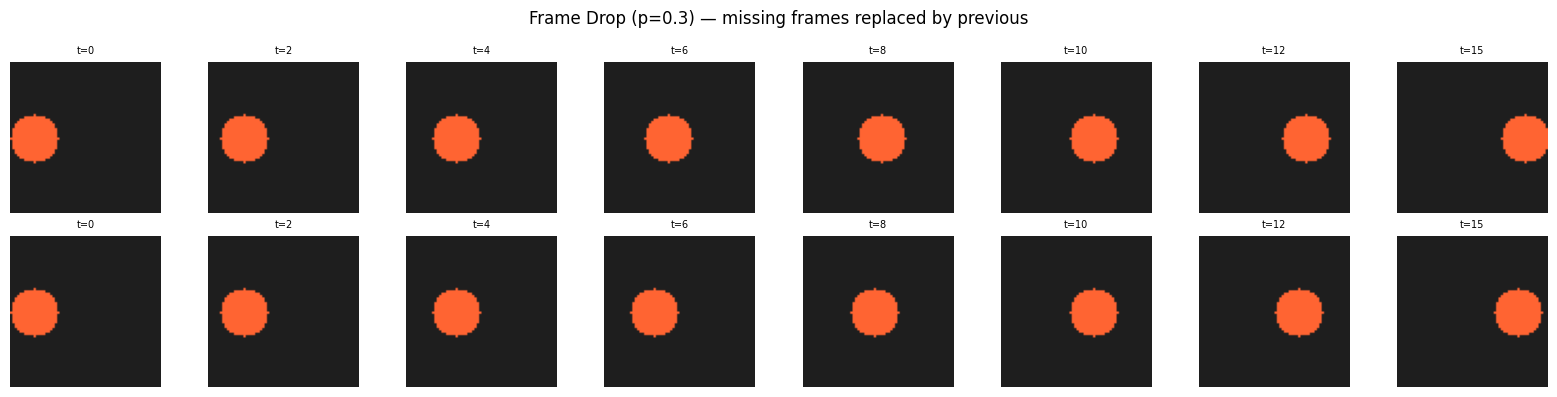

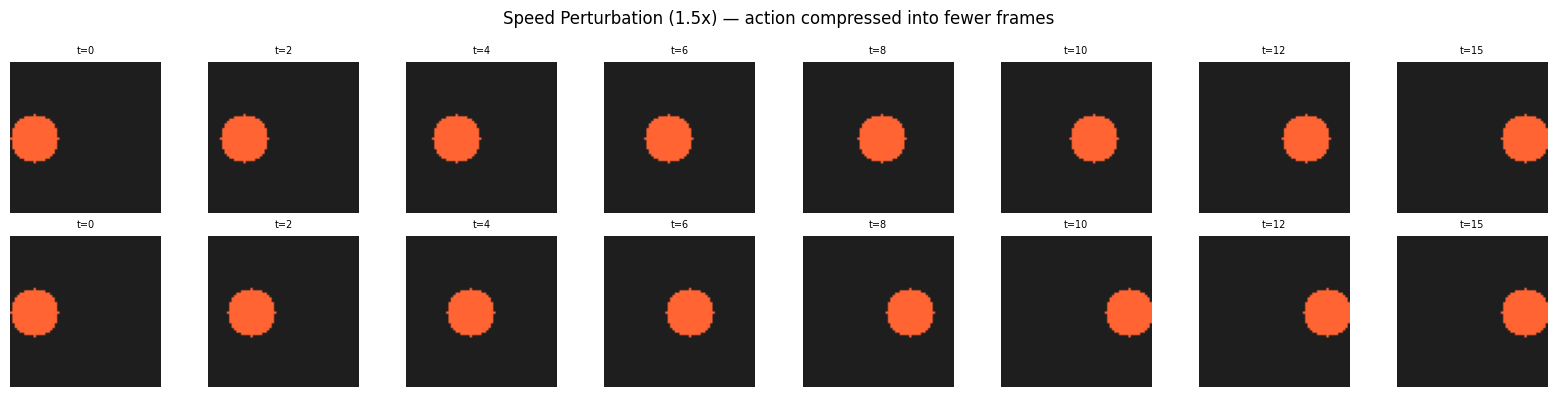

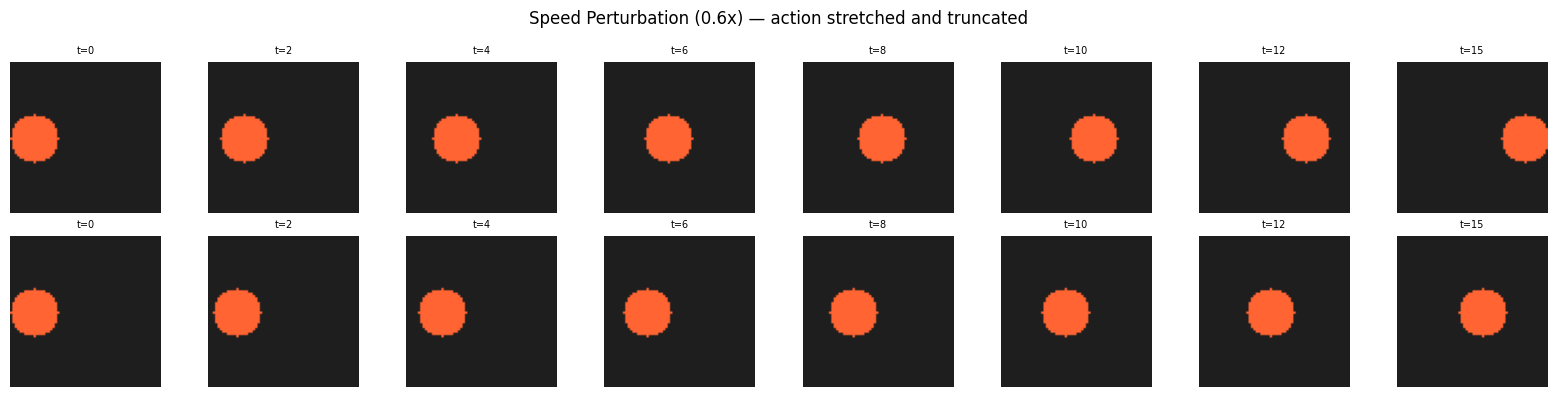

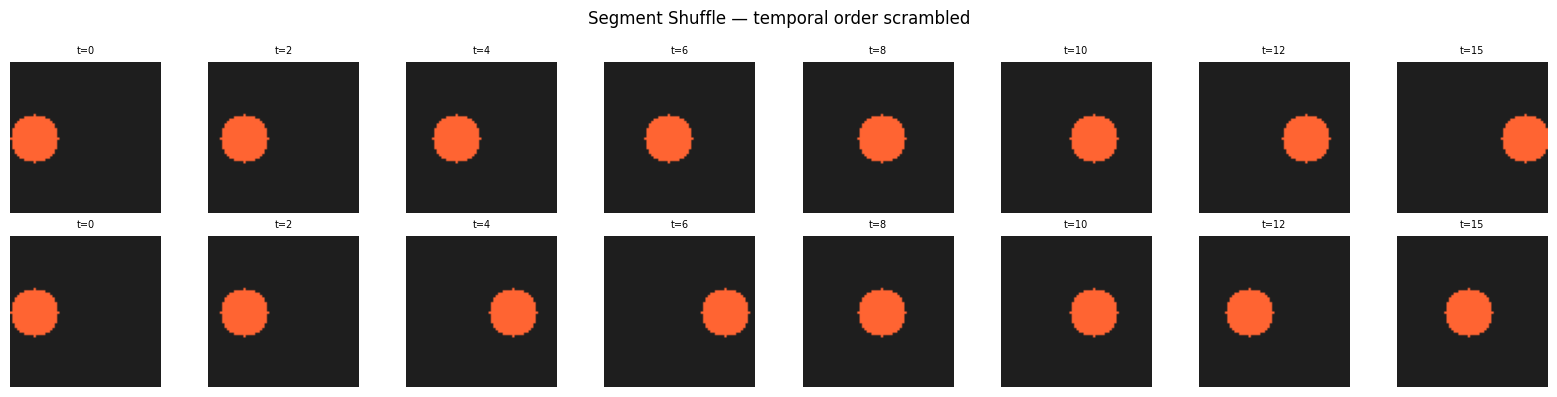

In [5]:
def temporal_reverse(video):
    """
    Reverse the temporal order of frames.
    The action plays backward. Useful for actions where direction is
    not meaningful (e.g. hand waving) but harmful for actions that
    have a clear temporal order (e.g. jumping).
    """
    return video[::-1].copy()


def temporal_frame_drop(video, drop_prob=0.2):
    """
    Randomly drop frames and replace each with the previous frame.
    Simulates packet loss in video streaming or frame rate variation.
    Makes the model robust to missing frames.
    """
    result = [video[0].copy()]   # always keep first frame
    for i in range(1, len(video)):
        if random.random() < drop_prob:
            result.append(result[-1].copy())   # repeat previous frame
        else:
            result.append(video[i].copy())
    return np.stack(result)


def temporal_speed_perturbation(video, speed_factor=None):
    """
    Speed up or slow down the video by resampling frames.

    speed_factor > 1: faster (fewer frames, action compressed)
    speed_factor < 1: slower (more frames, action stretched then truncated)

    Output always has the same number of frames as input.
    """
    T = len(video)
    if speed_factor is None:
        speed_factor = random.uniform(0.7, 1.5)

    # Original frame indices sampled at the new speed
    new_indices = np.linspace(0, T - 1, T) * speed_factor
    new_indices = np.clip(new_indices, 0, T - 1).astype(int)

    return video[new_indices]


def temporal_loop(video, n_loops=2):
    """
    Repeat the video sequence n_loops times, then truncate to original length.
    Simulates looping GIFs or repeating motion patterns.
    """
    T = len(video)
    looped = np.tile(video, (n_loops, 1, 1, 1))   # repeat along time axis
    return looped[:T]   # truncate to original length


def temporal_shuffle_segments(video, n_segments=4):
    """
    Split video into segments and shuffle their order.
    Used in self-supervised learning tasks where the model
    must predict the correct temporal order.
    """
    T = len(video)
    seg_len = T // n_segments
    segments = [video[i*seg_len:(i+1)*seg_len] for i in range(n_segments)]
    random.shuffle(segments)
    return np.concatenate(segments)


video = SAMPLE_VIDEOS[0]

show_video_aug(video, temporal_reverse(video),
               title='Temporal Reverse — action plays backward')

show_video_aug(video, temporal_frame_drop(video, drop_prob=0.3),
               title='Frame Drop (p=0.3) — missing frames replaced by previous')

show_video_aug(video, temporal_speed_perturbation(video, speed_factor=1.5),
               title='Speed Perturbation (1.5x) — action compressed into fewer frames')

show_video_aug(video, temporal_speed_perturbation(video, speed_factor=0.6),
               title='Speed Perturbation (0.6x) — action stretched and truncated')

show_video_aug(video, temporal_shuffle_segments(video, n_segments=4),
               title='Segment Shuffle — temporal order scrambled')

## 5. Temporal Segment Sampling

For action recognition, we rarely use all frames of a video.
We sample a fixed number of frames using different strategies.
The sampling strategy itself is a form of augmentation.


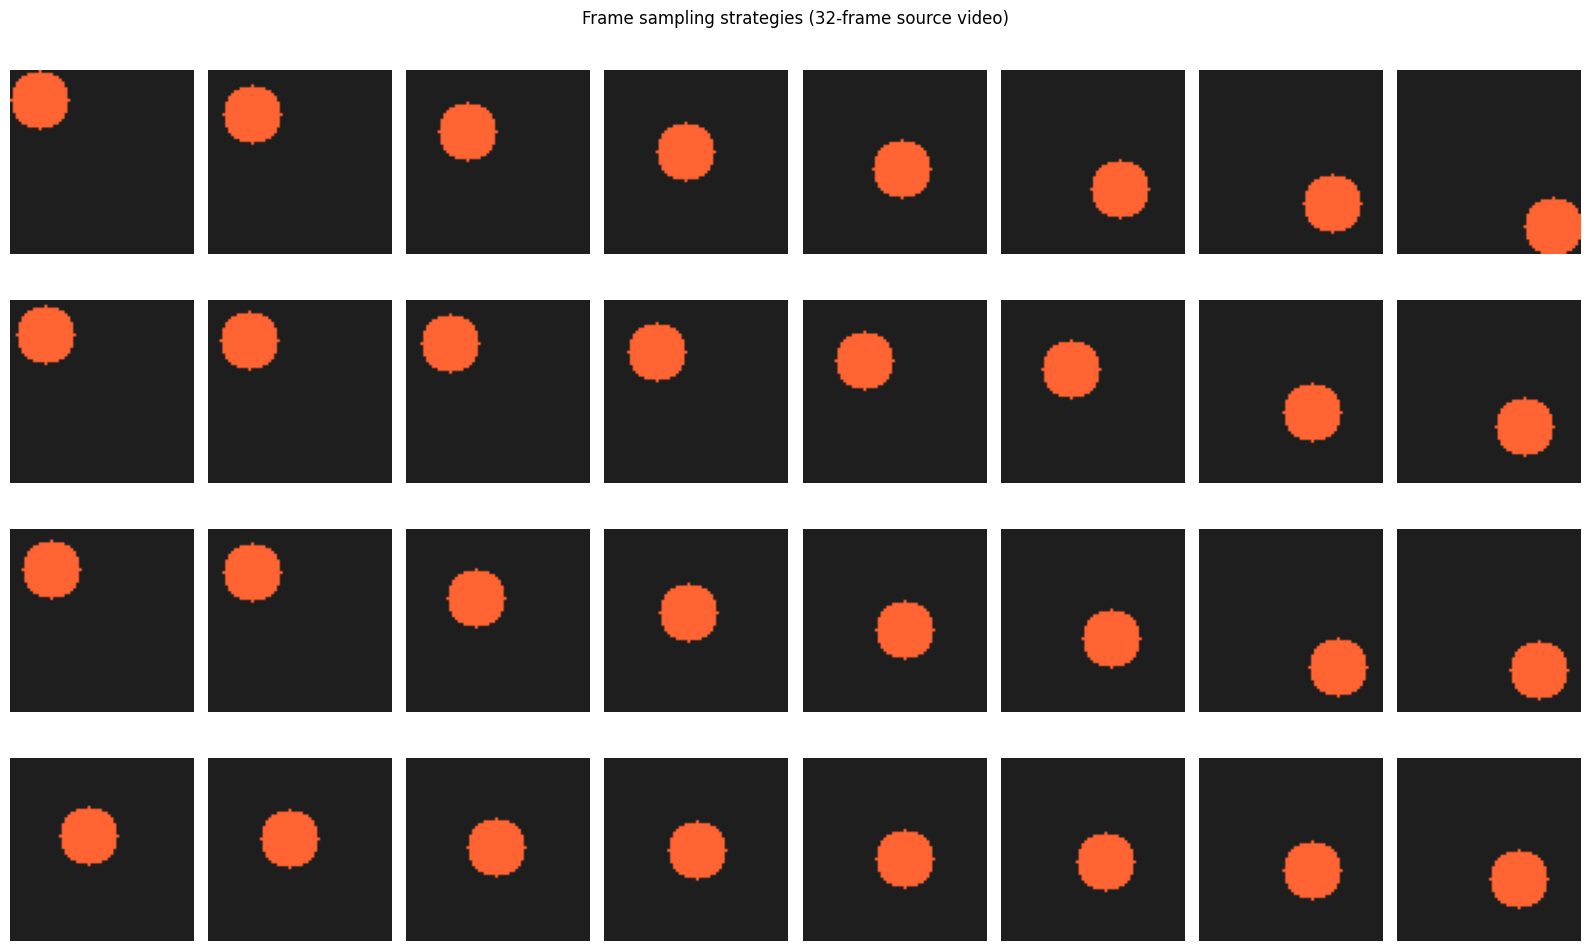

In [6]:
def uniform_sample(video, n_frames=8):
    """Sample n frames evenly spaced across the video."""
    T = len(video)
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    return video[indices]


def random_sample(video, n_frames=8):
    """Sample n frames at random positions (without replacement)."""
    T = len(video)
    indices = sorted(random.sample(range(T), min(n_frames, T)))
    return video[indices]


def segment_sample(video, n_segments=8):
    """
    Temporal Segment Network (TSN) strategy:
    divide video into N equal segments and sample one random frame per segment.
    Ensures coverage of the entire video duration.
    """
    T = len(video)
    seg_len = T // n_segments
    frames  = []
    for i in range(n_segments):
        start = i * seg_len
        end   = min(start + seg_len, T)
        idx   = random.randint(start, end - 1)
        frames.append(video[idx])
    return np.stack(frames)


def dense_sample(video, n_frames=8, clip_len=16):
    """
    Sample a contiguous clip of clip_len frames starting at a random position,
    then subsample n_frames from that clip.
    Mimics real action recognition: model sees a short, temporally dense clip.
    """
    T = len(video)
    start = random.randint(0, max(0, T - clip_len))
    clip  = video[start:start + clip_len]
    return uniform_sample(clip, n_frames)


# Visualise sampling strategies on a longer video
long_video = make_synthetic_video(n_frames=32, motion='diagonal')

strategies = [
    ('Uniform sample (8 from 32)',    uniform_sample(long_video, 8)),
    ('Random sample (8 from 32)',     random_sample(long_video, 8)),
    ('Segment sample (8 segments)',   segment_sample(long_video, 8)),
    ('Dense sample (clip of 12)',     dense_sample(long_video, 8, 12)),
]

fig, axes = plt.subplots(len(strategies), 8, figsize=(16, 2.5 * len(strategies)))
for row, (name, sampled) in enumerate(strategies):
    for col in range(8):
        axes[row, col].imshow(sampled[col])
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=8, rotation=0, labelpad=100, va='center')

plt.suptitle('Frame sampling strategies (32-frame source video)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Full Video Augmentation Pipeline


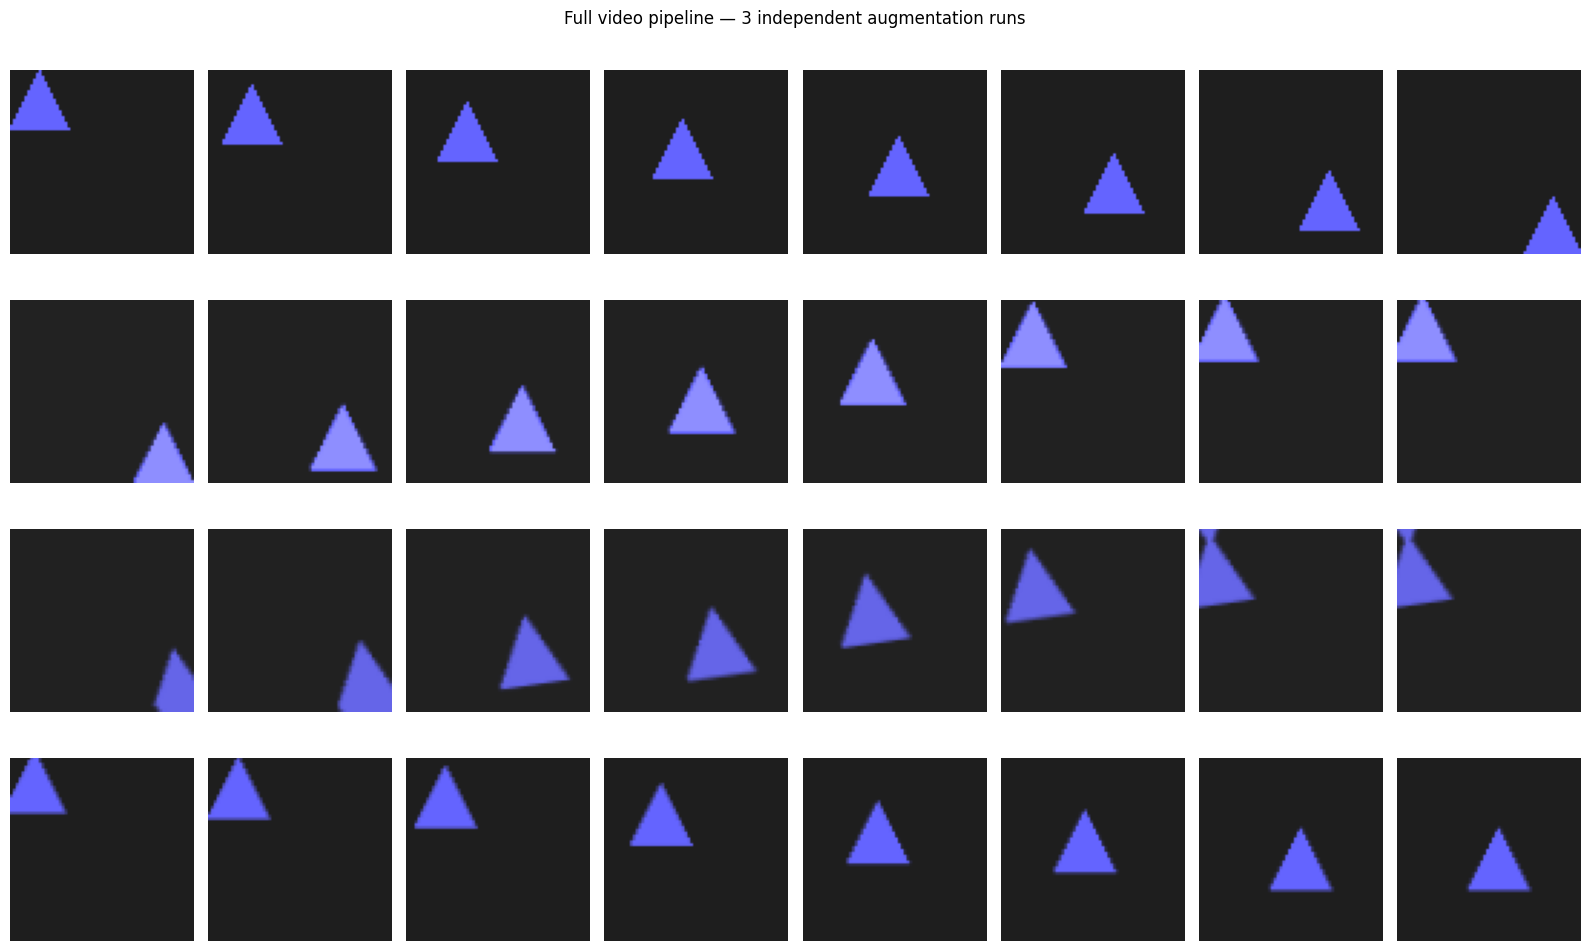

In [7]:
def video_augmentation_pipeline(video, training=True):
    """
    Complete video augmentation pipeline.

    Training: spatial + temporal augmentations
    Inference: only uniform temporal sampling + centre crop

    Input : numpy (T, H, W, C) uint8
    Output: numpy (n_frames, H, W, C) uint8 with n_frames=8
    """
    if training:
        # --- Temporal augmentation ---
        # 1. Random temporal reverse (20% chance)
        if random.random() < 0.2:
            video = temporal_reverse(video)

        # 2. Speed perturbation (uniform random)
        if random.random() < 0.5:
            video = temporal_speed_perturbation(video)

        # 3. Frame drop (mild)
        if random.random() < 0.3:
            video = temporal_frame_drop(video, drop_prob=0.15)

        # 4. Temporal segment sampling
        video = segment_sample(video, n_segments=8)

        # --- Spatial augmentation (applied to sampled frames) ---
        video = spatial_flip(video, p=0.5)
        video = spatial_crop(video, crop_frac=random.uniform(0.8, 1.0))
        if random.random() < 0.7:
            video = spatial_color_jitter(video)
        if random.random() < 0.4:
            video = spatial_rotate(video, max_angle=10)

    else:
        # Inference: deterministic sampling + no augmentation
        video = uniform_sample(video, n_frames=8)

    return video


# Visualise the full pipeline on different random seeds
video = SAMPLE_VIDEOS[2]

fig, axes = plt.subplots(4, 8, figsize=(16, 10))

# Row 0: original (uniform sampled)
orig_sampled = uniform_sample(video, 8)
for col in range(8):
    axes[0, col].imshow(orig_sampled[col])
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

# Rows 1-3: three different augmentation runs
for row in range(1, 4):
    random.seed(row * 100)
    aug_video = video_augmentation_pipeline(video.copy(), training=True)
    for col in range(8):
        axes[row, col].imshow(np.clip(aug_video[col], 0, 255).astype(np.uint8))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Aug run {row}', fontsize=9)

plt.suptitle('Full video pipeline — 3 independent augmentation runs', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Synthetic Video Dataset for Classification

We create a dataset with 4 classes (one per motion pattern)
and train a CNN to classify the motion type.


In [8]:
# Generate dataset: 4 classes, 200 videos each
MOTIONS    = ['horizontal', 'vertical', 'diagonal', 'bounce']
SHAPES     = ['circle', 'rectangle', 'triangle', 'circle']
N_PER_CLASS = 200
N_FRAMES    = 16

all_videos = []
all_labels = []

for label, (motion, shape) in enumerate(zip(MOTIONS, SHAPES)):
    for _ in range(N_PER_CLASS):
        color = tuple(np.random.randint(80, 255, 3).tolist())
        video = make_synthetic_video(
            n_frames=N_FRAMES, height=64, width=64,
            shape=shape, color=color, motion=motion
        )
        all_videos.append(video)
        all_labels.append(label)

all_videos = np.array(all_videos)   # (800, 16, 64, 64, 3)
all_labels = np.array(all_labels)   # (800,)

# Shuffle and split
idx = np.random.permutation(len(all_videos))
all_videos, all_labels = all_videos[idx], all_labels[idx]

split = int(0.8 * len(all_videos))
X_train_v, y_train_v = all_videos[:split], all_labels[:split]
X_test_v,  y_test_v  = all_videos[split:], all_labels[split:]

print(f'Train: {X_train_v.shape}, Test: {X_test_v.shape}')
print('Classes:', MOTIONS)

Train: (640, 16, 64, 64, 3), Test: (160, 16, 64, 64, 3)
Classes: ['horizontal', 'vertical', 'diagonal', 'bounce']


In [9]:
class VideoDataset(Dataset):
    """
    PyTorch Dataset for video clips.
    Returns tensors of shape (C, T, H, W) — the format expected by 3D CNNs.
    """
    def __init__(self, videos, labels, training=True, n_frames=8):
        self.videos   = videos
        self.labels   = labels
        self.training = training
        self.n_frames = n_frames

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video = self.videos[idx].copy()   # (T, H, W, C) uint8
        label = int(self.labels[idx])

        # Apply augmentation pipeline
        video = video_augmentation_pipeline(video, training=self.training)

        # Convert: (T, H, W, C) uint8 -> (C, T, H, W) float32 in [0, 1]
        video = torch.from_numpy(video).float() / 255.0   # (T, H, W, C)
        video = video.permute(3, 0, 1, 2)                  # (C, T, H, W)

        return video, label


BATCH_SIZE = 16

train_ds_aug   = VideoDataset(X_train_v, y_train_v, training=True)
train_ds_noaug = VideoDataset(X_train_v, y_train_v, training=False)
test_ds        = VideoDataset(X_test_v,  y_test_v,  training=False)

train_loader_aug   = DataLoader(train_ds_aug,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
train_loader_noaug = DataLoader(train_ds_noaug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader        = DataLoader(test_ds,         batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify tensor shapes
X_b, y_b = next(iter(train_loader_aug))
print(f'Batch shape: {X_b.shape}  (B, C, T, H, W)')
print(f'Label shape: {y_b.shape}')

Batch shape: torch.Size([16, 3, 8, 64, 64])  (B, C, T, H, W)
Label shape: torch.Size([16])


## 8. Video Classifier — CNN with Temporal Pooling


In [10]:
class VideoClassifier(nn.Module):
    """
    Simple video classifier:
    - 2D CNN extracts spatial features from each frame independently
    - Temporal average pooling aggregates across frames
    - Fully connected classifier head

    Input: (B, C, T, H, W)
    Process: reshape to (B*T, C, H, W) -> CNN -> reshape -> avg pool over T
    Output: (B, n_classes) logits
    """
    def __init__(self, n_classes=4):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                              # 64->32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                              # 32->16
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                       # 16->1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        B, C, T, H, W = x.shape

        # Reshape: process all frames as a batch
        x = x.permute(0, 2, 1, 3, 4)         # (B, T, C, H, W)
        x = x.reshape(B * T, C, H, W)         # (B*T, C, H, W)

        # Extract per-frame features
        x = self.cnn(x)                        # (B*T, 128, 1, 1)

        # Reshape back and average over time
        x = x.reshape(B, T, 128)              # (B, T, 128)
        x = x.mean(dim=1)                      # (B, 128) — temporal avg pooling

        return self.classifier(x)


# Test forward pass
test_model = VideoClassifier().to(device)
dummy = torch.zeros(4, 3, 8, 64, 64).to(device)
print(f'Output shape: {test_model(dummy).shape}  (expect [4, 4])')
total_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')

Output shape: torch.Size([4, 4])  (expect [4, 4])
Total parameters: 102,212


## 9. A/B Test: No Augmentation vs Full Video Pipeline


In [11]:
def train_video_model(train_loader, label='', epochs=20):
    torch.manual_seed(42)
    model     = VideoClassifier(n_classes=4).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0
    hist = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
        train_acc = correct / total

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        test_acc = correct / total
        best_test_acc = max(best_test_acc, test_acc)

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | train={train_acc:.4f} | test={test_acc:.4f}')

    print(f'[{label}] Best test accuracy: {best_test_acc:.4f}\n')
    return hist, best_test_acc


print('Training WITHOUT video augmentation...')
hist_noaug, acc_noaug = train_video_model(train_loader_noaug, label='No aug', epochs=20)

print('Training WITH video augmentation pipeline...')
hist_aug, acc_aug = train_video_model(train_loader_aug, label='Augmented', epochs=20)

Training WITHOUT video augmentation...
[No aug] Epoch  5 | train=0.9953 | test=1.0000
[No aug] Epoch 10 | train=1.0000 | test=1.0000
[No aug] Epoch 15 | train=1.0000 | test=1.0000
[No aug] Epoch 20 | train=1.0000 | test=1.0000
[No aug] Best test accuracy: 1.0000

Training WITH video augmentation pipeline...
[Augmented] Epoch  5 | train=0.7766 | test=0.8562
[Augmented] Epoch 10 | train=0.8469 | test=0.8625
[Augmented] Epoch 15 | train=0.9328 | test=1.0000
[Augmented] Epoch 20 | train=0.9469 | test=1.0000
[Augmented] Best test accuracy: 1.0000



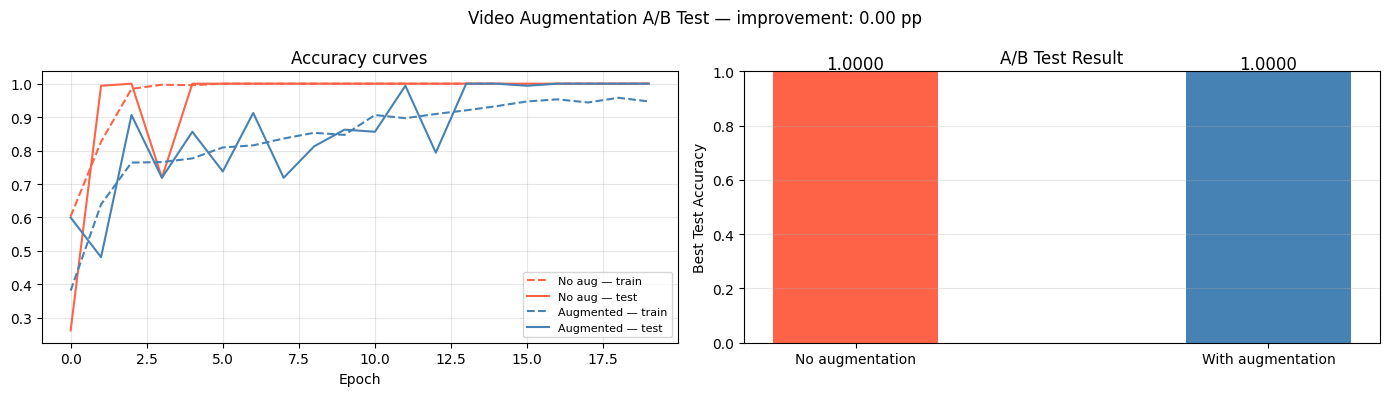

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_noaug['train_acc'], '--', color='tomato',    label='No aug — train')
axes[0].plot(hist_noaug['test_acc'],        color='tomato',    label='No aug — test')
axes[0].plot(hist_aug['train_acc'],   '--', color='steelblue', label='Augmented — train')
axes[0].plot(hist_aug['test_acc'],          color='steelblue', label='Augmented — test')
axes[0].set_title('Accuracy curves')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(
    ['No augmentation', 'With augmentation'],
    [acc_noaug, acc_aug],
    color=['tomato', 'steelblue'], width=0.4
)
for bar, acc in zip(bars, [acc_noaug, acc_aug]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.4f}', ha='center', fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Best Test Accuracy')
axes[1].set_title('A/B Test Result')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Video Augmentation A/B Test — improvement: {(acc_aug-acc_noaug)*100:.2f} pp',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## Summary

### The Golden Rule of Video Augmentation
**Spatial transforms must use the same parameters for every frame.**
Sample random parameters once, then loop over frames.
Never sample new parameters inside the per-frame loop.

### Augmentation Type Reference

| Type | Techniques | Key consideration |
|---|---|---|
| Spatial | Flip, Crop, Rotate, Colour jitter | Same params for all frames |
| Temporal | Reverse, Drop, Speed, Shuffle | Operates on frame sequence |
| Sampling | Uniform, Random, Segment (TSN), Dense | Done before spatial aug |

### Recommended Pipeline Order
```
1. Temporal: reverse / speed perturbation / frame drop
2. Temporal: frame sampling (segment or random)
3. Spatial:  flip, crop, rotate    (SAME params for all frames)
4. Spatial:  colour jitter          (SAME params for all frames)
5. Convert to tensor: (C, T, H, W) float32 in [0, 1]
```

**Next: Notebook 11** — Text / NLP Augmentation with nlpaug
